## Current workflow review copy

Synchronized with the completed 23 September 2026 uncalibrated engine run. Cluster assignments and household sampling are retained; thermal simulations now use cluster-median construction profiles at three median floor areas. Notebooks 05 onward use outputs/current. Notebooks 03–04 have no saved demonstration outputs in the current source. Read [the workflow](../../docs/ENGINE_WORKFLOW.md) and [interpretation](../../docs/INTERPRETATION.md). Packaging does not rerun calculations. Raw data, address-level outputs and interactive payloads are excluded.


In [ ]:
# Review copy: read saved results without running the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("Review copy: source inputs and third-party engines are excluded. Read saved results or use the Streamlit app.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 11 · Consistent PyPSA-LAEP interface

Full borough export: building-to-cluster mapping, retrofit options, physical quantities, paired R0/R1/R2 hourly demands, heat-pump COP and flexibility. Nearest-substation assignment is an inference; outside coverage, LSOA zones are explicitly assumed. Baseline and HP-conversion libraries are alternatives. Useful DHW excludes system losses; annual system/point-of-use splits are exported separately to avoid double counting. Fixed seasonal factors must not be reapplied to hourly HP electricity.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from ukubem import unified as U, reporting as R
OUT = U.OUT
U.interface()
import runpy
runpy.run_path(str(U.ROOT/'tests/verify_pypsa_interface.py'), run_name='__main__')
R.interface_figures()
display(json.loads((OUT/'pypsa_interface/checks.json').read_text()))
display(json.loads((OUT/'pypsa_interface/pypsa_import_check.json').read_text()))

LOCAL_PATH/unified.py:328: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[10.54372851 10.30444618 10.5779117  ... 20.70520335 15.08270933
 10.59225801]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  hp_lib.loc[idxs,'space_heat_w_per_m2']=HP.heat_pump_hourly(hp_lib.loc[idxs,'space_heat_w_per_m2'].to_numpy(),t)


PYPSA INTERFACE COMPLETE 2386 clusters


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'LOCAL_PATH/example_cluster_network.nc contains: buses, carriers, generators, links, loads


PASS: complete parquet totals and PyPSA network import


{'completed': True,
 'dwellings': 57300,
 'clusters': 2386,
 'baseline_heat_reconciled': True,
 'DHW_and_nonheating_reconciled': True,
 'thermal_profile_runs': 918,
 'representation_method': 'cluster_median_construction_three_median_areas_v1',
 'newly_converted_hp_library': 'Includes configured reshaping/uplift; do not apply to existing HPs again',
 'schema': 'Useful DHW excludes losses; use cluster_end_use_weights for baseline system/POU split. COP is a conversion efficiency, never a load.'}

{'passed': True,
 'stored_parquet_rows': 62704080,
 'all_package_totals_reconciled': True,
 'pypsa_version': '1.0.6',
 'example_cluster': 'C.Det.2|Wcav|LSOA:E01030442',
 'snapshots': 8760,
 'loads': 3,
 'COP_links': 2,
 'optimization_run': False,
 'example_boundary': 'Useful DHW demonstration. Add declared DHW losses/technology split for a full baseline fuel reconstruction; do not interpret this example as calibrated dispatch.'}

PyPSA inputs are useful space heat, useful DHW and non-heating electricity—not already-converted electricity for those heat services.

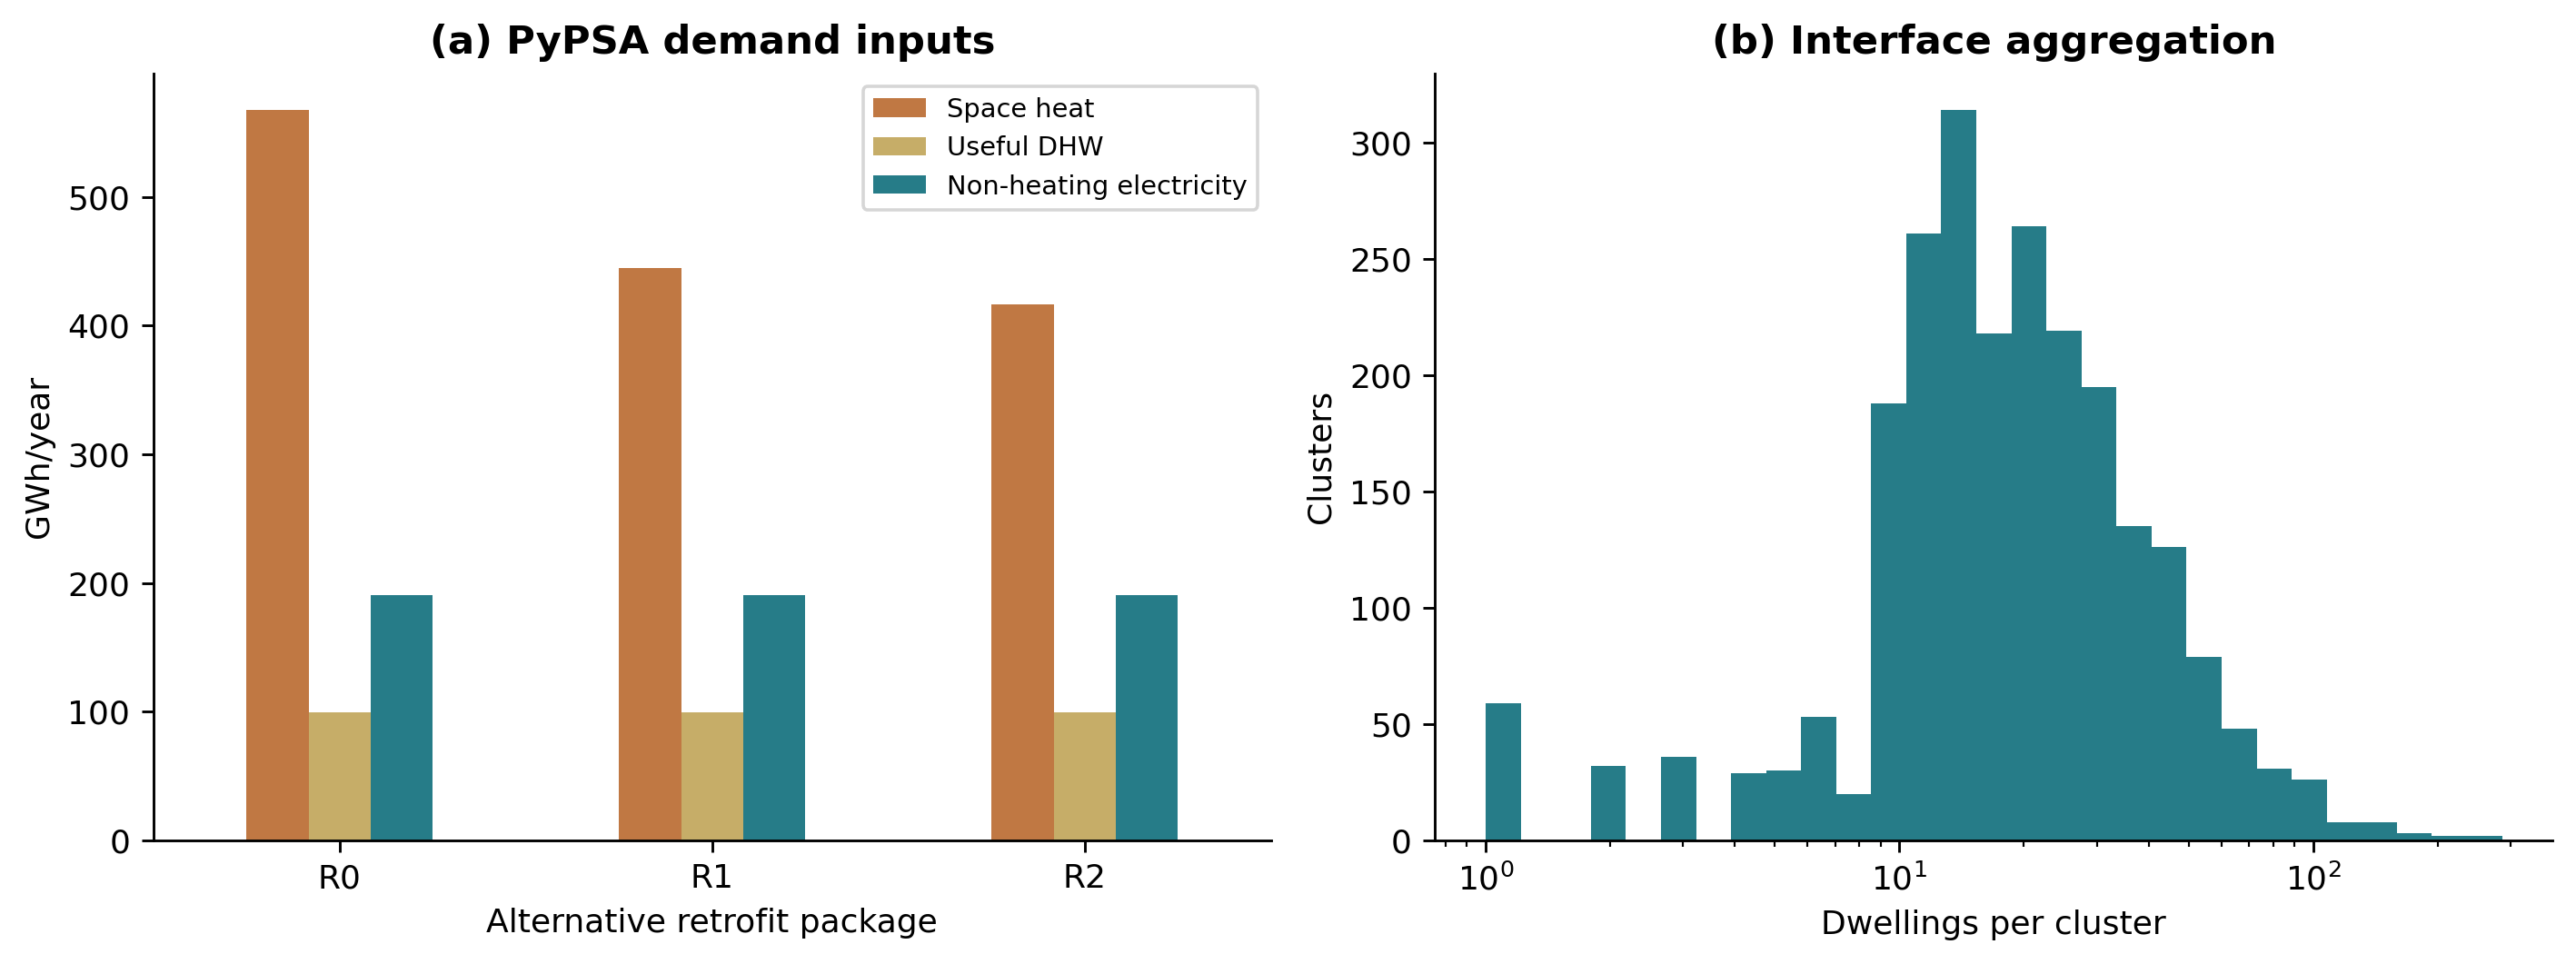

In [2]:
display(Image(filename=str(OUT/'figures/11_pypsa_interface_summary.png')))

In [3]:
display(Markdown((OUT/'pypsa_interface/README_pypsa_interface.md').read_text(encoding='utf-8')))

[Review copy: identifier-bearing output omitted.]
